## Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

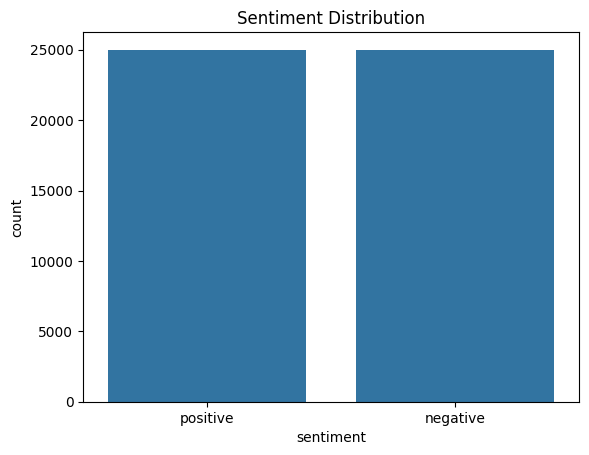

In [5]:
sns.countplot(x=df["sentiment"])
plt.title("Sentiment Distribution")
plt.show()

## Preprocessing

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [9]:
df["preprocessed_dataset"] = df["review"].apply(preprocess_text)

In [10]:
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [12]:
print("Original:\n", df["review"].iloc[0])
print("\nCleaned:\n", df["preprocessed_dataset"].iloc[0])

Original:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

## Train-Test Split


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    df["preprocessed_dataset"],
    df["label"],
    test_size=0.2,
    random_state=42
)

## TF-IDF with ngrams

In [15]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)  # unigram + bigram
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Model Training

### Naive Bayes

In [16]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)

### Logistic Regression

In [17]:
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

lr_preds = lr_model.predict(X_test_tfidf)

### Support Vector Machine

In [20]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

svm_preds = svm_model.predict(X_test_tfidf)

## Evaluation

In [21]:
def evaluate_model(y_true, y_pred, name):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\n", classification_report(y_true, y_pred))

In [22]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

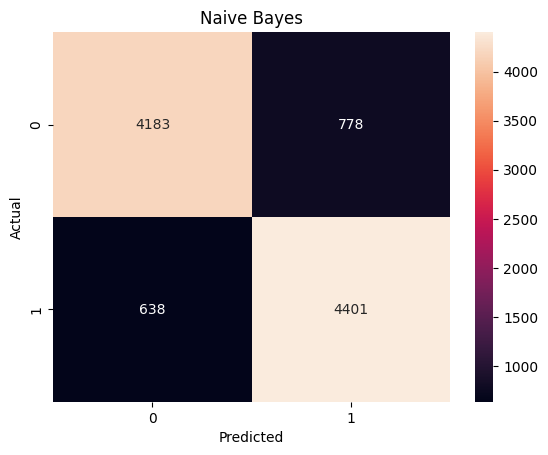

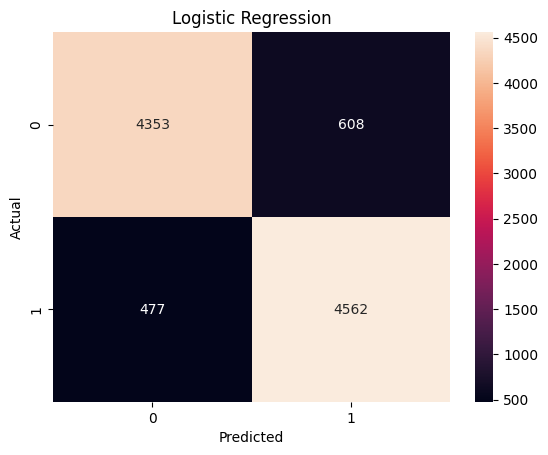

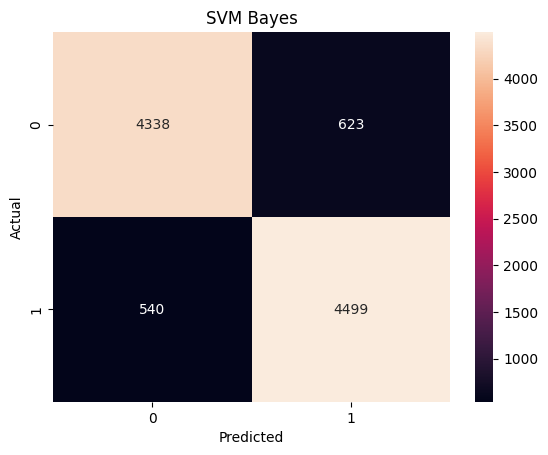

In [25]:
plot_confusion(y_test, nb_preds, "Naive Bayes")
plot_confusion(y_test, lr_preds, "Logistic Regression")
plot_confusion(y_test, svm_preds, "SVM Bayes")

## Model Interpretation

### Most Important Words

In [26]:
feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

top_positive = sorted(zip(coefficients, feature_names), reverse=True)[:10]
top_negative = sorted(zip(coefficients, feature_names))[:10]

print("Top Positive Words:\n", top_positive)
print("\nTop Negative Words:\n", top_negative)

Top Positive Words:
 [(np.float64(6.8765029770517865), 'excellent'), (np.float64(6.352741248628759), 'great'), (np.float64(5.211847564337859), 'perfect'), (np.float64(4.9559693025313), 'wonderful'), (np.float64(4.938262264117915), 'amazing'), (np.float64(4.788801563183557), 'brilliant'), (np.float64(4.313116516849788), 'hilarious'), (np.float64(4.2153657975631615), 'loved'), (np.float64(4.19993422028603), 'favorite'), (np.float64(4.106784484660022), 'one best')]

Top Negative Words:
 [(np.float64(-9.325407544036429), 'worst'), (np.float64(-7.526086947976051), 'awful'), (np.float64(-7.11852707564161), 'boring'), (np.float64(-6.878227703426573), 'waste'), (np.float64(-6.655748388564236), 'bad'), (np.float64(-5.94441452040383), 'poor'), (np.float64(-5.9194908049196355), 'terrible'), (np.float64(-5.235278755282292), 'dull'), (np.float64(-5.14093923421903), 'nothing'), (np.float64(-5.013914440315058), 'poorly')]


## Prediction Function

In [27]:
def predict_text(text, model):
    vec = vectorizer.transform([text])
    prediction = model.predict(vec)
    return "Positive" if prediction[0] == 1 else "Negative"

In [33]:
print("Naive Bayes model: ", predict_text("I hated this movie", nb_model))
print("Logistic Regression model: ", predict_text("I hated this movie", lr_model))
print("Support Vector Machine model: ", predict_text("I hated this movie", svm_model))

Naive Bayes model:  Negative
Logistic Regression model:  Negative
Support Vector Machine model:  Negative


In [34]:
print("Naive Bayes model: ", predict_text("I did not like that movie", nb_model))
print("Logistic Regression model: ", predict_text("I did not like that movie", lr_model))
print("Support Vector Machine model: ", predict_text("I did not like that movie", svm_model))

Naive Bayes model:  Negative
Logistic Regression model:  Negative
Support Vector Machine model:  Negative


In [35]:
print("Naive Bayes model: ", predict_text("The movie was fun to watch", nb_model))
print("Logistic Regression model: ", predict_text("The movie was fun to watch", lr_model))
print("Support Vector Machine model: ", predict_text("The movie was fun to watch", svm_model))

Naive Bayes model:  Positive
Logistic Regression model:  Positive
Support Vector Machine model:  Positive


## In This Notebook We Built:

- Full sentiment analysis pipeline
- Cleaned real-world text (IMDb)
- Used TF-IDF with n-grams
- Trained and compared models
- Visualized performance
- Interpreted model decisions
- Built a prediction function